## 프로젝트 수행 방법
주 데이터는 cars.csv이며, 보조자료로 brand.csv도 준비되어있으니 함께 활용해보세요.  
이번 프로젝트에서는 "중고차 가격 예측 모델"을 가정하여 데이터를 준비해볼 수도 있고, "중고차 특성에 따른 클러스터링"을 가정하여 데이터를 준비해볼 수도 있습니다.  
아직 머신러닝 알고리즘을 학습하기 전 단계이니, 배웠던 내용을 최대한 활용하여 다양하게 데이터를 변환해보세요.  
만약 이전에 배웠던 학습 내용이 익숙하지 않다면 이전 내용을 다시 한번 복습해 주세요. 🤗  


Step 1. 이것만큼은 꼭 해보세요!   
프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제하고 변환하되, 아래 내용만큼은 반드시 실습해봅시다.   

cars.csv와 brand.csv의 데이터 합치기   
[힌트] cars.csv의 title 변수로부터 브랜드 데이터를 추출할 수 있습니다.   

카테고리형 변수를 숫자 형태로 변환하기   
[힌트] Engine, Emission Class 변수에 주목하세요!   

결측치 처리하기   
[힌트] Service history 변수의 결측치는 'Unknown'으로 채우고, 결측치 변수가 일정 개수 이상 포함된 데이터는 제거합니다.   

Scaler 활용해보기   
기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)   
     
Step 2. 이런것도 해볼 수 있어요!   
자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.   
국가별 총 브랜드 개수는?   
상관관계가 높은 변수들이 있는지 확인해보세요.   

### 🔹 라이브러리 / 데이터 불러오기/ 변수저장

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

car_df = pd.read_csv('../00_Dataset/cars.csv') #brand데이터와 머지한 데이터
brand_df = pd.read_csv('../00_Dataset/brand.csv')
car_rw = car_df.copy() #원본 오리지널 데이터, 건들지 말것

In [4]:
display(car_df)
# display(car_df.info())
display(car_rw)



,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full


,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full


### 🔹 브랜드 데이터셋 살펴보기

In [5]:

display(brand_df)
display(brand_df.info())


,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States
5,volvo,Sweden
6,peugeot,France
7,bmw,Germany
8,citroen,France
9,mercedes-benz,Germany


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    48 non-null     object
 1   country  48 non-null     object
dtypes: object(2)
memory usage: 900.0+ bytes


None

### 🔹 자동차 데이터셋의 Title칼럼에서 name 분리 + brand_df 컬럼 merge

브랜드 데이터셋에 타이틀과 컨트리 밸류를 car_df에 합치고 중복되거나 필요없이 생성된 컬럼은 삭제   
새로 추가된 네임컬럼은 타이틀 컬럼 옆으로 이동하여 재배치

In [6]:
#car_df에 title컬럼에서 name분리
car_df["name"] = (
    car_df["title"]
    .astype(str)
    .str.split()
    .str[0]
    .str.lower()
    .str.strip()
)
display(car_df)

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,name
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,renault
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,audi
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,bmw
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,honda


In [7]:
car_df["name"] = car_df["name"].str.lower().str.strip()
brand_df["title"] = brand_df["title"].str.lower().str.strip()

In [8]:
brand_df.columns

Index(['title', 'country'], dtype='object')

In [9]:
car_df = car_df.merge(
    brand_df[["title", "country"]],
    left_on="name",
    right_on="title",
    how="left"
)
display(car_df)

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,name,title_y,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,vauxhall,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,renault,renault,France
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,audi,audi,Germany
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,bmw,bmw,Germany
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,honda,honda,Japan


In [10]:
car_df = car_df.drop(columns=["title_y"]).rename(columns={"title_x": "title"})

In [11]:
display(car_df)

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,name,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,renault,France
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,audi,Germany
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,bmw,Germany
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,honda,Japan


In [12]:
# car_df = car_df.drop(columns=["country_y","country_x"])

# display(car_df)

In [13]:
display(car_df)

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,name,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,renault,France
3683,AUDI A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,audi,Germany
3684,BMW 3 SERIES,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,bmw,Germany
3685,HONDA ACCORD,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,honda,Japan


In [14]:
cols = car_df.columns.tolist()

# name 컬럼을 title 바로 뒤로 이동
cols.insert(cols.index("title") + 1, cols.pop(cols.index("name")))

car_df = car_df[cols]

display(car_df)

,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,France
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,Japan


### 🔹 데이터의 구조 확인

In [15]:
display(car_df.shape)
display(car_df)
display(car_df.describe())
car_df.info
car_df.isnull().sum()


(3687, 15)

,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,France
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,Japan


,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


title                   0
name                    0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1411
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3147
country                 0
dtype: int64

| 컬럼명 | 의미 |
| --- | --- |
| title | 차량의 전체 이름 (브랜드, 모델명, 세부 트림 포함) |
| name | 차량 브랜드명 (소비자 인식 기준, 예: audi, mini, hyundai) |
| Price | 차량 판매 가격 |
| Mileage(miles) | 차량 주행 거리 (마일 단위) |
| Registration_Year | 차량 최초 등록 연도 |
| Previous Owners | 이전 차량 소유자 수 |
| Fuel type | 차량 연료 유형 (예: Petrol, Diesel, Hybrid, Electric) |
| Body type | 차량 차체 유형 (예: Sedan, Hatchback, SUV) |
| Engine | 엔진 사양 및 배기량 정보 |
| Gearbox | 변속기 유형 (Automatic / Manual) |
| Doors | 차량 도어 수 |
| Seats | 차량 좌석 수 |
| Emission Class | 배출가스 규제 등급 (예: Euro 5, Euro 6) |
| Service history | 차량 정비 및 서비스 이력 여부 |
| country | 차량 브랜드의 제조국 |



### 🔹 결측치를 제거해보자


In [16]:
#결측치 파악
missing_summary = (
    car_df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "결측치_개수", "mean": "결측치_비율"})
)

missing_summary["결측치_비율"] *= 100
display(missing_summary.sort_values("결측치_비율", ascending=False))



,결측치_개수,결측치_비율
Service history,3147.0,85.353946
Previous Owners,1411.0,38.269596
Emission Class,87.0,2.359642
Engine,45.0,1.220504
Seats,35.0,0.949281
Doors,25.0,0.678058
title,0.0,0.000000
name,0.0,0.000000
Price,0.0,0.000000
Mileage(miles),0.0,0.000000


엔진수, 시트수, 도어수가 결측치는 작지만 차량에 대한 물리적 스펙 정확도를 알 수 없으므로 결측항목만 제거하자

In [17]:

car_df = car_df.dropna(subset=["Emission Class"])

missing_summary = (
    car_df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "결측치_개수", "mean": "결측치_비율"})
)

missing_summary["결측치_비율"] *= 100
display(missing_summary.sort_values("결측치_비율", ascending=False))


,결측치_개수,결측치_비율
Service history,3066.0,85.166667
Previous Owners,1356.0,37.666667
Seats,6.0,0.166667
Engine,1.0,0.027778
title,0.0,0.000000
name,0.0,0.000000
Price,0.0,0.000000
Mileage(miles),0.0,0.000000
Registration_Year,0.0,0.000000
Fuel type,0.0,0.000000


In [18]:
display(car_df.shape)
display(car_df)
display(car_df.describe())
# display(car_df.info())
car_df.isnull().sum()
# 처음 데이터 구조 (3687, 15)

(3600, 15)

,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,France
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,Japan


,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3600.000000,3.600000e+03,3600.000000,2244.000000,3600.000000,3594.000000
mean,5790.285000,8.152356e+04,2011.930833,2.807041,4.316944,4.898442
std,4512.130445,3.955813e+04,4.777569,1.543463,0.988032,0.575483
min,400.000000,1.000000e+00,1992.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,3999.500000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7999.000000,1.032000e+05,2016.000000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2023.000000,9.000000,5.000000,7.000000


title                   0
name                    0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1356
Fuel type               0
Body type               0
Engine                  1
Gearbox                 0
Doors                   0
Seats                   6
Emission Class          0
Service history      3066
country                 0
dtype: int64

정비이력은 NAN아니면 Full구조니까 0과 1로 바꾸자

In [19]:
car_df["service_history_flag"] = (car_df["Service history"] == "Full").astype(int)

missing_summary = (
    car_df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "결측치_개수", "mean": "결측치_비율"})
)

missing_summary["결측치_비율"] *= 100
display(missing_summary.sort_values("결측치_비율", ascending=False))
display(car_df)

,결측치_개수,결측치_비율
Service history,3066.0,85.166667
Previous Owners,1356.0,37.666667
Seats,6.0,0.166667
Engine,1.0,0.027778
title,0.0,0.000000
name,0.0,0.000000
Price,0.0,0.000000
Mileage(miles),0.0,0.000000
Registration_Year,0.0,0.000000
Fuel type,0.0,0.000000


,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country,service_history_flag
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic,0
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom,1
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea,0
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom,1
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,France,0
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany,0
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany,0
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,Japan,1


In [20]:
car_df["service_history_flag"] = (car_df["Service history"] == "Full").astype(int)

In [21]:
car_df[["Service history", "service_history_flag"]].head(10)

,Service history,service_history_flag
0,NaN,0
1,Full,1
2,NaN,0
3,Full,1
4,NaN,0
5,NaN,0
6,NaN,0
7,NaN,0
9,NaN,0
10,Full,1


In [22]:
display(car_df)

,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country,service_history_flag
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,Czech Republic,0
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,United Kingdom,1
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,South Korea,0
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,United Kingdom,1
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,United Kingdom,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN,France,0
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany,0
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN,Germany,0
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full,Japan,1


In [23]:
car_df = car_df.drop(columns=["Service history"])

missing_summary = (
    car_df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "결측치_개수", "mean": "결측치_비율"})
)

missing_summary["결측치_비율"] *= 100
display(missing_summary.sort_values("결측치_비율", ascending=False))
display(car_df)
display(car_df.columns)

,결측치_개수,결측치_비율
Previous Owners,1356.0,37.666667
Seats,6.0,0.166667
Engine,1.0,0.027778
title,0.0,0.000000
name,0.0,0.000000
Price,0.0,0.000000
Mileage(miles),0.0,0.000000
Registration_Year,0.0,0.000000
Fuel type,0.0,0.000000
Body type,0.0,0.000000


,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,country,service_history_flag
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,Czech Republic,0
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,United Kingdom,1
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,South Korea,0
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,United Kingdom,1
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,United Kingdom,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,France,0
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,Germany,0
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,Germany,0
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Japan,1


Index(['title', 'name', 'Price', 'Mileage(miles)', 'Registration_Year',
       'Previous Owners', 'Fuel type', 'Body type', 'Engine', 'Gearbox',
       'Doors', 'Seats', 'Emission Class', 'country', 'service_history_flag'],
      dtype='object')

👉 Previous Owners칼럼은 중요한데 결측치가 많아, 결측치가 있는 항목은 0으로 처리할까?   
하지만 의미 해석에 오류가 생길 수 있으니까 정보 없음”을 별도 값으로 가져가자. 
기존 소유자가 7명까지도 있는 차량과 1명이던 차량의 가격은 중요한 차이가 발생되므로 그 칼럼은 유지하되 
결측치를 표시한 컬럼을 따로 두고 소팅을 용이하게 하자. 
즉 결측을 의미 있는 상태로 보존하는 방식.

In [24]:
car_df["previous_owners_missing"] = car_df["Previous Owners"].isna().astype(int)
car_df["previous_owners_missing"] = 1 - car_df["previous_owners_missing"]
display(car_df[["Previous Owners", "previous_owners_missing"]].head(10))

missing_summary = (
    car_df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "결측치_개수", "mean": "결측치_비율"})
)

missing_summary["결측치_비율"] *= 100
display(missing_summary.sort_values("결측치_비율", ascending=False))
display(car_df)


,Previous Owners,previous_owners_missing
0,3.0,1
1,4.0,1
2,NaN,0
3,5.0,1
4,NaN,0
5,3.0,1
6,NaN,0
7,NaN,0
9,5.0,1
10,NaN,0


,결측치_개수,결측치_비율
Previous Owners,1356.0,37.666667
Seats,6.0,0.166667
Engine,1.0,0.027778
title,0.0,0.000000
name,0.0,0.000000
Price,0.0,0.000000
Mileage(miles),0.0,0.000000
Registration_Year,0.0,0.000000
Fuel type,0.0,0.000000
Body type,0.0,0.000000


,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,country,service_history_flag,previous_owners_missing
0,SKODA FABIA,skoda,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,Czech Republic,0,1
1,VAUXHALL CORSA,vauxhall,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,United Kingdom,1,1
2,HYUNDAI I30,hyundai,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,South Korea,0,0
3,MINI HATCH,mini,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,United Kingdom,1,1
4,VAUXHALL CORSA,vauxhall,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,United Kingdom,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,RENAULT MEGANE,renault,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,France,0,1
3683,AUDI A4,audi,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,Germany,0,0
3684,BMW 3 SERIES,bmw,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,Germany,0,0
3685,HONDA ACCORD,honda,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Japan,1,0


이전 차량 소유자의 결측치가 30%를 넘는 비율이지만 가격에 중요한 요인이 될 수 있으므로 원데이터는 남기고 결측치가 있는 항목과 없는 항목으로 따로 구분된 컬럼을 추가하였다. 차량 정비여부는 정비여부 없을시 0, 있을시 1로 처리하여 EDA에 활용하고자 한다

# 질문:
1.중고차 가격은 어떤 특성에서 눈에 띄는 차이나 패턴을 보이는가?”

2.그 특성들을 기준으로, 중고차는 가격 분포가 다른 집단으로 자연스럽게 나뉘는가?

### 🔹 결측치 처리한 데이터프레임 훑어보기

In [25]:
display(car_df.sort_values(by='Price', ascending=False).head(50))
# display(car_df)
car_df.columns


,title,name,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,country,service_history_flag,previous_owners_missing
3212,MERCEDES-BENZ GLE CLASS,mercedes-benz,33900,92000,2019,1.0,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,Germany,0,1
2936,LAND ROVER RANGE ROVER SPORT,land,30000,46000,2017,2.0,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,United Kingdom,0,1
3224,BMW X3 SERIES,bmw,28240,45155,2019,1.0,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,Germany,0,1
3102,SEAT ATECA,seat,25995,222,2023,NaN,Petrol,SUV,1.5L,Manual,5.0,5.0,Euro 6,Spain,0,0
3230,LAND ROVER RANGE ROVER SPORT,land,25995,36363,2015,NaN,Diesel,SUV,3.0L,Automatic,5.0,5.0,Euro 5,United Kingdom,0,0
2913,LAND ROVER RANGE ROVER EVOQUE,land,25100,26994,2019,NaN,Diesel,SUV,2.0L,Manual,5.0,5.0,Euro 6,United Kingdom,0,0
3130,AUDI A6,audi,25000,34364,2019,1.0,Diesel,Estate,2.0L,Automatic,5.0,5.0,Euro 6,Germany,0,1
2183,DS AUTOMOBILES DS 9,ds,24770,16864,2021,1.0,Petrol Plug-in Hybrid,Saloon,1.6L,Automatic,4.0,5.0,Euro 6,France,0,1
2862,LAND ROVER RANGE ROVER EVOQUE,land,24444,22189,2019,NaN,Diesel,SUV,2.0L,Manual,5.0,5.0,Euro 6,United Kingdom,0,0
3213,MAZDA MAZDA6 TOURER,mazda,23910,23178,2020,1.0,Petrol,Estate,2.5L,Automatic,5.0,5.0,Euro 6,Japan,0,1


Index(['title', 'name', 'Price', 'Mileage(miles)', 'Registration_Year',
       'Previous Owners', 'Fuel type', 'Body type', 'Engine', 'Gearbox',
       'Doors', 'Seats', 'Emission Class', 'country', 'service_history_flag',
       'previous_owners_missing'],
      dtype='object')

<span style="color: #ffd700;">Previous Owners,Fuel type,Body type,Engine,Gearbox,Emission Class,country</span>    

가격과 관련이 있을것 같은 칼럼 후보들, 그리고 가격과 변수들의 상관관계 분석해보자
| 변수 타입 | 방법                        |
| ----- | ------------------------- |
| 수치형   | 상관계수 (Pearson / Spearman) |
| 범주형   | 그룹 평균 / boxplot           |
| 이진 변수 | 평균 비교                     |
| 텍스트   | 가공 후 사용                   |


In [26]:
# 먼저 변수 타입 분리 (필수)
numeric_cols = car_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = car_df.select_dtypes(include=["object"]).columns.tolist()

numeric_cols, categorical_cols

(['Price',
  'Mileage(miles)',
  'Registration_Year',
  'Previous Owners',
  'Doors',
  'Seats',
  'service_history_flag',
  'previous_owners_missing'],
 ['title',
  'name',
  'Fuel type',
  'Body type',
  'Engine',
  'Gearbox',
  'Emission Class',
  'country'])

In [27]:
# 수치형 변수들은 가격과 피어슨 상관관계로 알아본다
# 0.0 ~ 0.1 거의 없음
# 0.1 ~ 0.3 약함
# 0.3 ~ 0.5 중간
# 0.5 ~ 0.7 꽤 강함
# 0.7 ~ 1.0 매우 강함

corr_price = (
    car_df[numeric_cols]
    .corr()["Price"]
    .sort_values(ascending=False)
)

display(corr_price)


Price                      1.000000
Registration_Year          0.780659
service_history_flag       0.140067
Doors                      0.113836
previous_owners_missing    0.055328
Seats                     -0.025287
Previous Owners           -0.485050
Mileage(miles)            -0.502784
Name: Price, dtype: float64

Registration_Year (0.723)
강한 양의 상관 → 등록 연도가 최신일수록 가격이 높아짐.

service_history_flag (0.139)
약한 양의 상관 → 정비이력이 있는 차량이 가격이 약간 높은 경향.

Doors (0.113)
매우 약한 양의 상관 → 문이 많을수록 약간 비쌀 가능성.

previous_owners_missing (0.054)
거의 상관 없음.

Seats (-0.027)
거의 상관 없음.

Previous Owners (-0.479)
중간 정도의 음의 상관 → 이전 소유자가 많을수록 가격이 낮아짐.

Mileage(miles) (-0.500)
중간 정도의 음의 상관 → 주행거리가 많을수록 가격이 낮아짐.  

<span style="color: #ffd700;">
요약하면: 가격은 연식과 가장 관련이 크고(+), 주행거리와 이전 소유자 수와는 반대로 움직이는 경향(-)이 가장 뚜렷.<br>
즉, 가격과 등록년도는 함께 올라가거나 내려가며 주행거리와 이전 소유자는 적을수록 가격이 올라가는 패턴을 보인다</span>

In [28]:
# Spearman (순서 관계, 비선형 포함)
# Mileage, Previous Owners 같은 변수엔 이게 더 좋아.
# 위에서 했던 Pearson vs Spearman 차이도 같이 보는 게 포인트.

corr_price_s = (
    car_df[numeric_cols]
    .corr(method="spearman")["Price"]
    .sort_values(ascending=False)
)

display(corr_price_s)


Price                      1.000000
Registration_Year          0.826372
service_history_flag       0.167047
Doors                      0.118692
previous_owners_missing    0.025360
Seats                     -0.030424
Previous Owners           -0.529765
Mileage(miles)            -0.576635
Name: Price, dtype: float64

Registration_Year (0.818)
매우 강한 양의 상관 → 연식이 최신일수록 가격이 높아지는 경향이 뚜렷함.

service_history_flag (0.164)
약한 양의 상관 → 정비이력이 있는 차량이 약간 더 비싼 경향.

Doors (0.121)
약한 양의 상관 → 문 수가 많을수록 가격이 약간 높은 경향.

previous_owners_missing (0.021)
거의 상관 없음.

Seats (-0.030)
거의 상관 없음.

Previous Owners (-0.524)
중간~강한 음의 상관 → 이전 소유자 수가 많을수록 가격이 낮아짐.

Mileage(miles) (-0.575)
중간~강한 음의 상관 → 주행거리가 많을수록 가격이 낮아짐.

<span style="color: #ffd700;">
요약하면: 연식은 가격과 가장 강한 정(+)의 관계,<br>
주행거리와 이전 소유자 수는 가격과 뚜렷한 음(-)의 관계를 보임.</span>

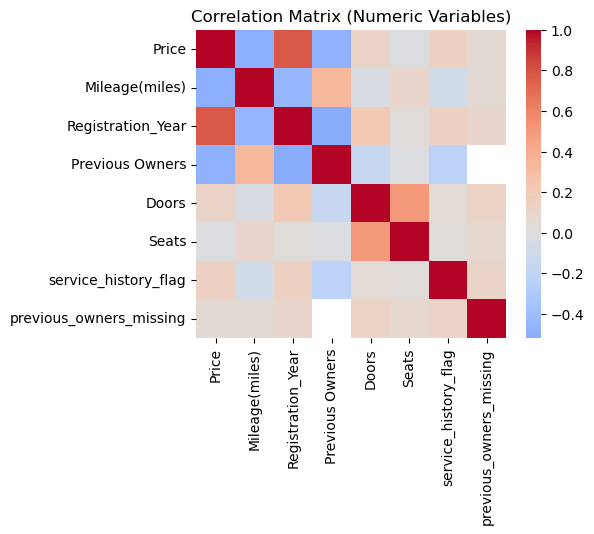

In [29]:
#히트맵보기

plt.figure(figsize=(5, 4))
sns.heatmap(
    car_df[numeric_cols].corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()


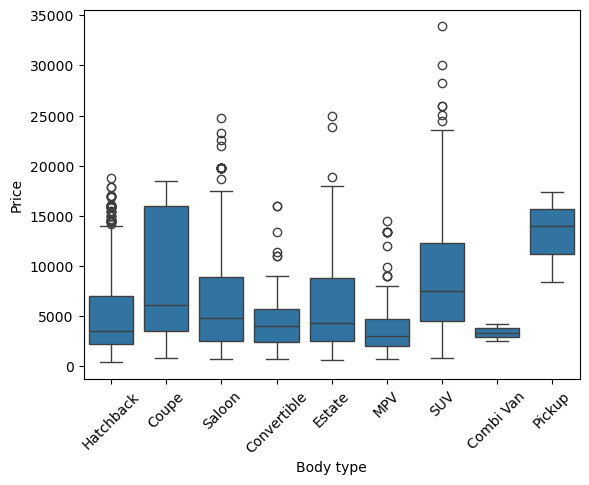

Body type
Combi Van         2
Pickup            3
Convertible     106
Coupe           134
MPV             148
Estate          167
Saloon          354
SUV             459
Hatchback      2227
Name: count, dtype: int64

In [30]:
# 범주형 변수 ↔ Price 관계
# (1) 브랜드 / 바디타입 등

car_df.groupby("Body type")["Price"].mean().sort_values(ascending=False)

sns.boxplot(x="Body type", y="Price", data=car_df)
plt.xticks(rotation=45)
plt.show()

# #박스플롯보다는 막대그래프로 보자
# sns.countplot(x="Body type", data=car_df, order=car_df["Body type"].value_counts().index)
# plt.xticks(rotation=45)
# plt.show()

# sns.barplot(x="Body type", y="Price", data=car_df, estimator="mean", errorbar=None)
# plt.xticks(rotation=45)
# plt.ylabel("Average Price")
# plt.show()

# sns.barplot(x="Body type", y="Price", data=car_df, estimator="median", errorbar=None)
# plt.xticks(rotation=45)
# plt.ylabel("Median Price")
# plt.show()

car_df["Body type"].value_counts(ascending=True).head(30)


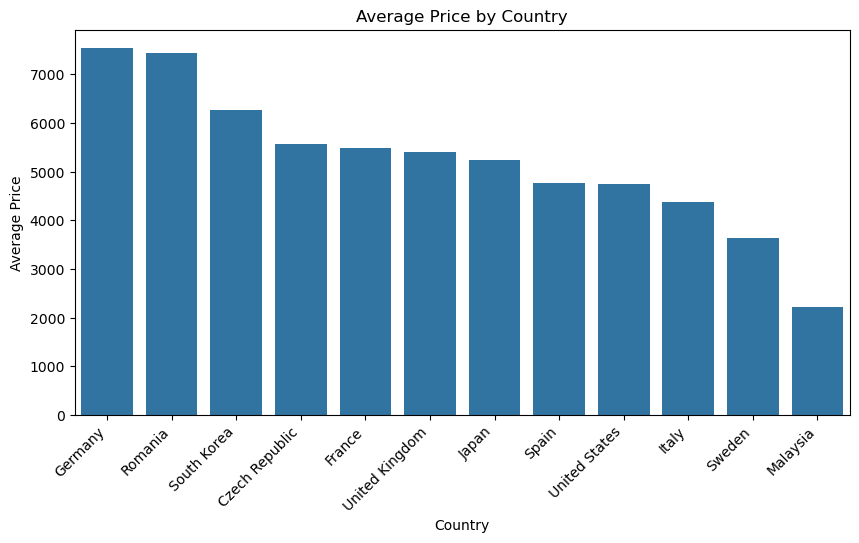

In [31]:
# 제조 국가별 가격과의 관계

car_df.groupby("country")["Price"].mean().sort_values(ascending=False)

country_price = car_df.groupby("country")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_price.index, y=country_price.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Price")
plt.xlabel("Country")
plt.title("Average Price by Country")
plt.show()


<span style="color: #ffd700;">
제조 국가별 평균 가격을 보면 Germany가 가장 높고(약 7,500), 그다음은 Romania, South Korea 순이다. <br> 반면 Malaysia는 평균 가격이 가장 낮다(약 2,227). 즉 국가에 따라 평균 가격 수준 차이가 꽤 크다</span>

In [49]:
# 이진 변수 ↔ Price

car_df.groupby("service_history_flag")["Price"].mean()

service_history_flag
0    5526.564905
1    7304.453184
Name: Price, dtype: float64

In [50]:
summary = []

# numeric
for col in numeric_cols:
    if col != "Price":
        summary.append({
            "variable": col,
            "type": "numeric",
            "pearson_corr": car_df[col].corr(car_df["Price"]),
            "spearman_corr": car_df[col].corr(car_df["Price"], method="spearman")
        })

summary_df = pd.DataFrame(summary).sort_values("spearman_corr", ascending=False)
display(summary_df)


,variable,type,pearson_corr,spearman_corr
1,Registration_Year,numeric,0.780659,0.826372
5,service_history_flag,numeric,0.140067,0.167047
3,Doors,numeric,0.113836,0.118692
6,previous_owners_missing,numeric,0.055328,0.025360
4,Seats,numeric,-0.025287,-0.030424
2,Previous Owners,numeric,-0.485050,-0.529765
0,Mileage(miles),numeric,-0.502784,-0.576635


<span style="color: #ffd700;">Price와의 상관관계(피어슨/스피어만)</span>    

가격과의 상관관계를 보면 Registration_Year가 가장 높은 양의 상관을 보이며(Pearson 0.781, Spearman 0.826), 연식이 최신일수록 가격이 높아지는 경향이 강하다. 반대로 Mileage(miles)와 Previous Owners는 중간 정도의 음의 상관을 보여 주행거리와 이전 소유자가 많을수록 가격이 낮아지는 경향이 있다. service_history_flag, Doors, previous_owners_missing, Seats는 상관계수가 작아 가격과의 관계가 약하거나 거의 없다.

### 🔹 컬럼 하나씩 뜯어보기

In [33]:
def eda_column(df, col, target="Price"):
    print(f"\n===== {col} =====")
    
    # 기본 정보
    display(df[col].describe(include="all"))
    display(df[col].isna().sum())
    
    # 수치형
    if df[col].dtype != "object":
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df[col], bins=30, ax=ax[0])
        ax[0].set_title(f"{col} Distribution")
        
        sns.boxplot(x=df[col], ax=ax[1])
        ax[1].set_title(f"{col} Boxplot")
        plt.show()
        
        if target in df.columns:
            sns.scatterplot(x=df[col], y=df[target])
            plt.title(f"{col} vs {target}")
            plt.show()
    
    # 범주형
    else:
        display(df[col].value_counts().head(10))

In [34]:
eda_column(car_df, "title")


===== title =====


count               3600
unique               428
top       VAUXHALL CORSA
freq                 222
Name: title, dtype: object

np.int64(0)

title
VAUXHALL CORSA           222
FORD FOCUS               161
VAUXHALL ASTRA           154
FORD FIESTA              128
BMW 3 SERIES             116
RENAULT CLIO             105
VOLKSWAGEN POLO           96
TOYOTA YARIS              80
MINI HATCH                78
MERCEDES-BENZ C CLASS     58
Name: count, dtype: int64

 <span style="color: #1e90ff;">1. Title 컬럼 분석결과</span>  

총 3687개의 항목중 455개의 범주값이 있으며 그중 가장 많이 등장한 값은 VAUXHALL CORSA이며, 223개의 빈도(횟수)를 가지고 있다.   

모델명이 너무 세분화되어 있는가?   
brand 분석과 분리되어 있는가?

In [35]:
eda_column(car_df, "name")


===== name =====


count         3600
unique          45
top       vauxhall
freq           547
Name: name, dtype: object

np.int64(0)

name
vauxhall         547
ford             408
bmw              265
volkswagen       263
peugeot          245
toyota           187
renault          174
mercedes-benz    165
nissan           147
audi             145
Name: count, dtype: int64

<span style="color: #1e90ff;">2. name 컬럼 분석결과</span>  
 
총 3687개의 항목중 48개의 범주값이 있으며 그중 가장 많이 등장한 값은 VAUXHALL 이며, 550개의 빈도(횟수)를 가지고 있다.

브랜드별 가격 차이가 존재하는가?  
표본 수가 너무 적은 브랜드는?   

In [36]:
eda_column(car_df, "country")


===== country =====


count        3600
unique         12
top       Germany
freq          844
Name: country, dtype: object

np.int64(0)

country
Germany           844
United Kingdom    720
Japan             590
France            519
United States     437
South Korea       178
Italy             127
Czech Republic     63
Spain              59
Sweden             46
Name: count, dtype: int64

<span style="color: #1e90ff;">3. Country 컬럼 분석결과</span>  
 
총 3687개의 항목중 12개의 국가별 범주값이 있으며 그중 가장 많이 등장한 값은 germany이며, 863개의 빈도(횟수)를 가지고 있다.

국가별 가격 분포  

유럽 vs 비유럽 비교

In [37]:
eda_column(car_df, "Fuel type")


===== Fuel type =====


count       3600
unique         5
top       Petrol
freq        2323
Name: Fuel type, dtype: object

np.int64(0)

Fuel type
Petrol                   2323
Diesel                   1208
Petrol Hybrid              41
Petrol Plug-in Hybrid      27
Diesel Hybrid               1
Name: count, dtype: int64

<span style="color: #1e90ff;">4. Fuel  Type 컬럼 분석결과</span>  
 
총 3687개의 항목중 6개의 연료방식 범주값이 있으며 그중 가장 많이 등장한 값은 Petrol(가솔린)이며, 2362개의 빈도(횟수)를 가지고 있다.

- 전기차/하이브리드 가격 프리미엄

- 표본 수 불균형


===== Price =====


count     3600.000000
mean      5790.285000
std       4512.130445
min        400.000000
25%       2490.000000
50%       3999.500000
75%       7999.000000
max      33900.000000
Name: Price, dtype: float64

np.int64(0)

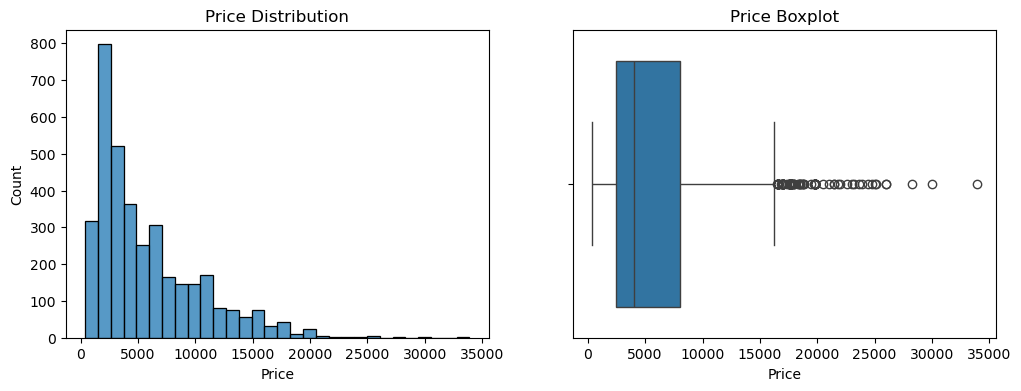

In [38]:
eda_column(car_df, "Price", target=None)

<span style="color: #1e90ff;">5. Price 컬럼 분석결과</span>  
 
 총 3,687개의 값이 있으며 평균은 약 5,787, 중앙값은 4,000이다. 값의 범위는 400부터 33,900까지로 넓고, 표준편차가 약 4,481이라 변동 폭이 크다. 하위 25%는 2,490 이하, 상위 25%는 7,995 이상으로 나타난다.   
 큰 값들이 평균을 끌어올리는 구조.

 로그 변환 필요 여부 판단



===== Mileage(miles) =====


count    3.600000e+03
mean     8.152356e+04
std      3.955813e+04
min      1.000000e+00
25%      5.698400e+04
50%      8.000000e+04
75%      1.032000e+05
max      1.110100e+06
Name: Mileage(miles), dtype: float64

np.int64(0)

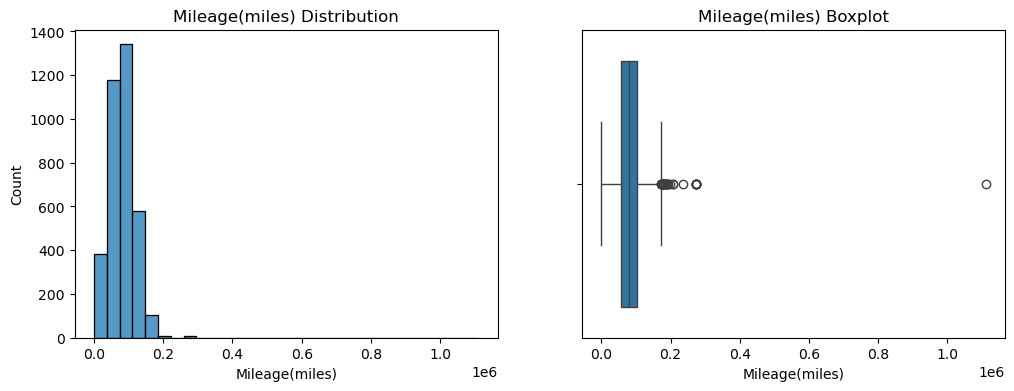

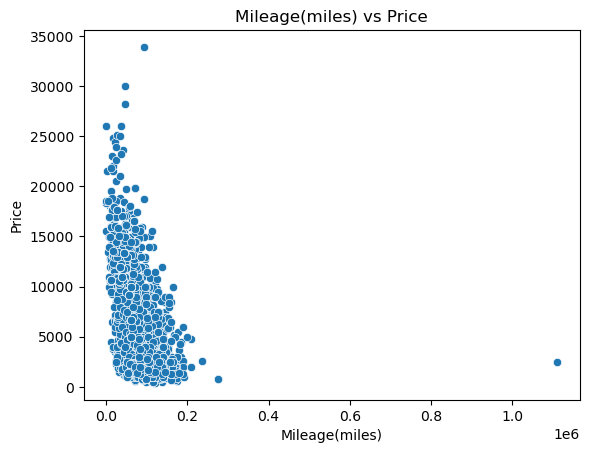

In [39]:
eda_column(car_df, "Mileage(miles)")

<span style="color: #1e90ff;">6. Mileage 컬럼 분석결과</span>  
 
 마일리지는 총 3,687개의 값이 있으며 평균은 약 81,329마일, 중앙값은 80,000마일이다.    
 범위는 1마일부터 1,110,100마일까지로 매우 넓고, 표준편차가 약 39,417마일이라 변동 폭이 큰 편이다.    하위 25%는 56,984마일 이하, 상위 25%는 103,000마일 이상으로 나타난다.

- Price와 음의 상관

- 로그 or clipping 고려


===== Registration_Year =====


count    3600.000000
mean     2011.930833
std         4.777569
min      1992.000000
25%      2008.000000
50%      2012.000000
75%      2016.000000
max      2023.000000
Name: Registration_Year, dtype: float64

np.int64(0)

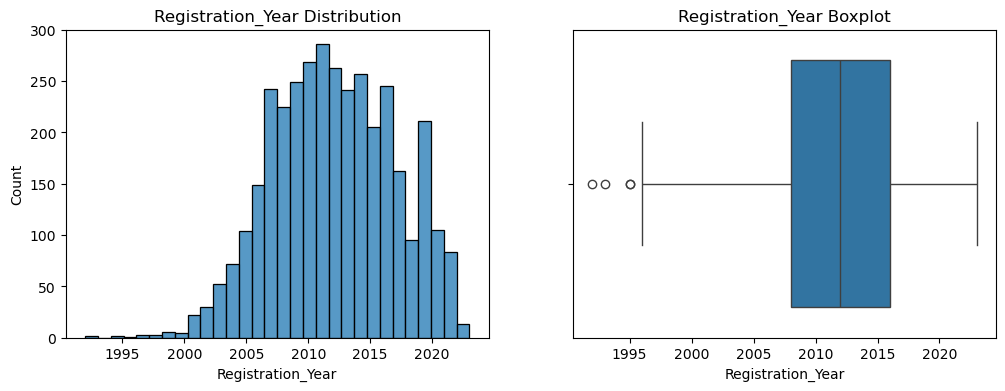

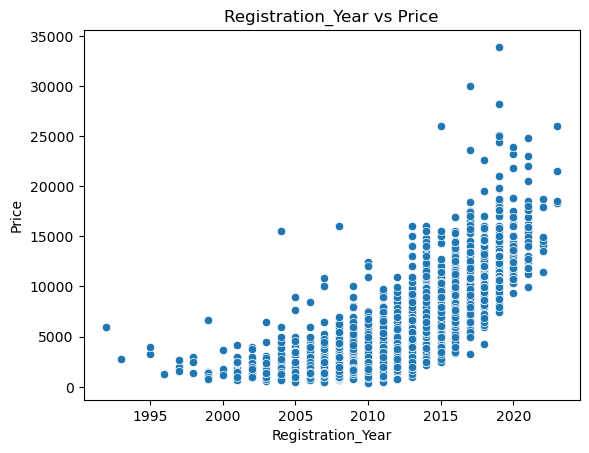

In [40]:
eda_column(car_df, "Registration_Year")

<span style="color: #1e90ff;">7. Registration_Year 컬럼 분석결과</span>  
Registration_Year(차량등록연도)는 총 3,687개의 값이 있으며 평균은 약 2011.85년, 중앙값은 2012년이다. 최솟값은 1953년, 최댓값은 2025년으로 범위가 넓고, 표준편차는 약 5.08년이다. 하위 25%는 2008년 이하, 상위 25%는 2015.5년 이상으로 나타난다.

 - 연식 → 차량 나이로 변환 고려


===== Previous Owners =====


count    2244.000000
mean        2.807041
std         1.543463
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: Previous Owners, dtype: float64

np.int64(1356)

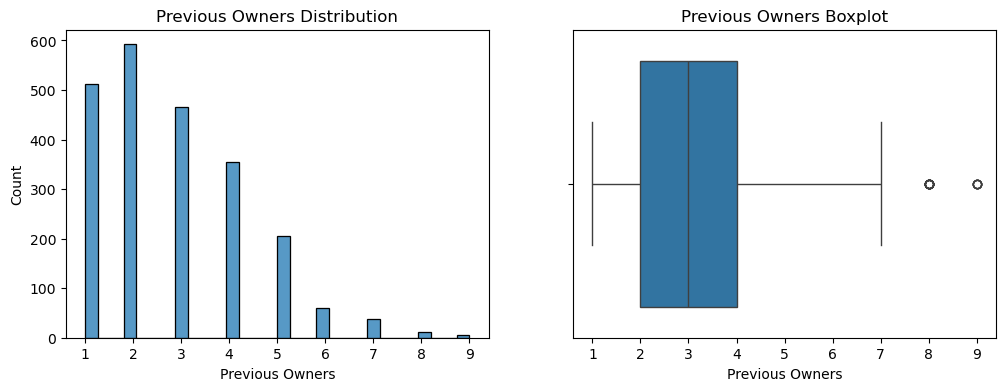

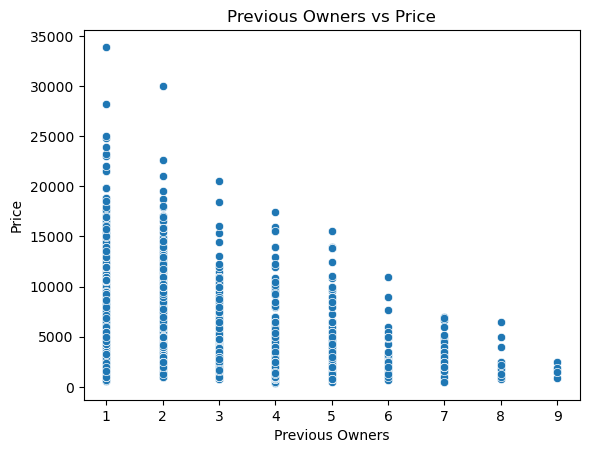

In [41]:
eda_column(car_df, "Previous Owners")

<span style="color: #1e90ff;">8. Previous Owners 컬럼 분석결과</span>  
이전 소유자 수는 총 2,276개의 값이 있으며 평균은 약 2.81명, 중앙값은 3명이다. 최소 1명에서 최대 9명까지 분포하고, 표준편차가 약 1.55명이라 변동 폭이 있다. 하위 25%는 2명 이하, 상위 25%는 4명 이상으로 나타난다.




===== service_history_flag =====


count    3600.000000
mean        0.148333
std         0.355479
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: service_history_flag, dtype: float64

np.int64(0)

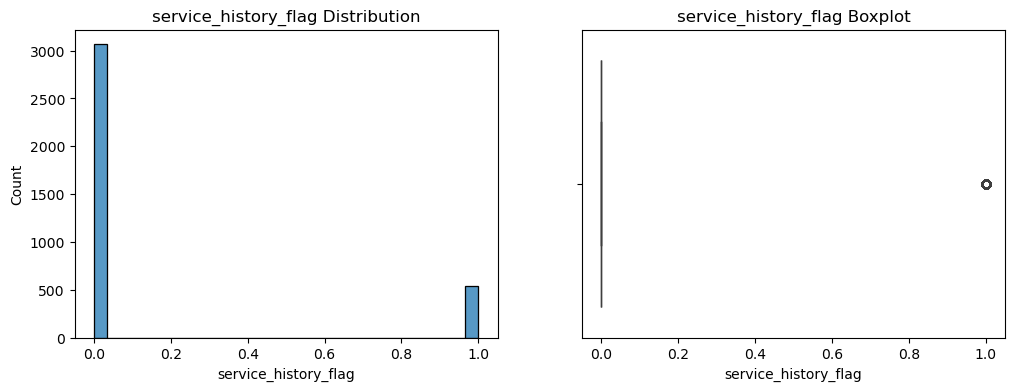

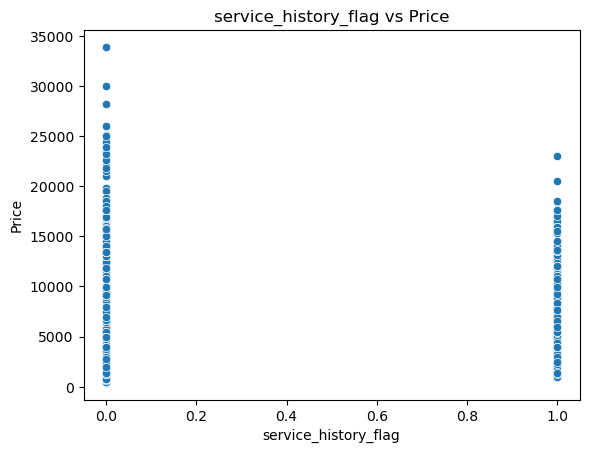

In [42]:
eda_column(car_df, "service_history_flag")

<span style="color: #1e90ff;">9. service_history 컬럼 분석결과</span>    
정비이력은 총 3,687개의 값이 있으며, 평균은 0.146으로 1(정비이력 있음)의 비율이 약 14.6% 정도임을 의미한다.  
즉, 전체 중 약 14.65%가 정비 이력이 있으며, 약 85.35%는 정비 이력이 없다는 것을 알 수 있다.

- 정비 이력이 가격 프리미엄을 만드는가?

In [43]:
eda_column(car_df, "Body type")


===== Body type =====


count          3600
unique            9
top       Hatchback
freq           2227
Name: Body type, dtype: object

np.int64(0)

Body type
Hatchback      2227
SUV             459
Saloon          354
Estate          167
MPV             148
Coupe           134
Convertible     106
Pickup            3
Combi Van         2
Name: count, dtype: int64

<span style="color: #1e90ff;">10. body Type 컬럼 분석결과</span>    
중고차 매물의 Body type은 총 3,687개의 값이 있으며 서로 다른 유형은 10개다. 가장 많이 등장한 유형은 Hatchback이고 2,280회 나타났다.

- SUV / Hatchback / Sedan 가격 차이 존재?

- 표본 수 적은 body type 있는지

- luxury body type(SUV, Coupe)에 프리미엄 있는지

In [44]:
car_df["Engine"].head(10)
eda_column(car_df, "Engine")


===== Engine =====


count     3599
unique      34
top       1.6L
freq       732
Name: Engine, dtype: object

np.int64(1)

Engine
1.6L    732
2.0L    545
1.2L    516
1.4L    421
1.0L    324
1.5L    290
1.3L    166
1.8L    153
3.0L     77
2.2L     75
Name: count, dtype: int64

<span style="color: #1e90ff;">11. Engine 컬럼 분석결과</span>    
Engine 컬럼은 총 3,642개의 값이 있으며 서로 다른 값은 34개다. 가장 많이 등장한 값은 1.6L이고 736회 나타났다.

In [45]:
eda_column(car_df, "Gearbox")


===== Gearbox =====


count       3600
unique         2
top       Manual
freq        2850
Name: Gearbox, dtype: object

np.int64(0)

Gearbox
Manual       2850
Automatic     750
Name: count, dtype: int64

<span style="color: #1e90ff;">12. Gearbox 컬럼 분석결과</span>    
Gearbox 컬럼은 총 3,687개의 값이 있으며 서로 다른 유형은 2개다. 가장 많이 등장한 유형은 Manual(수동형)이며 2,870회 나타났다.


===== Doors =====


count    3600.000000
mean        4.316944
std         0.988032
min         2.000000
25%         3.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Doors, dtype: float64

np.int64(0)

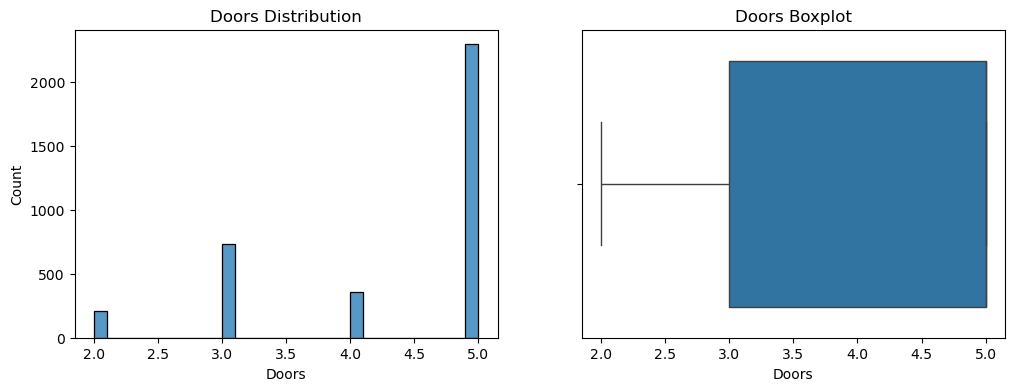

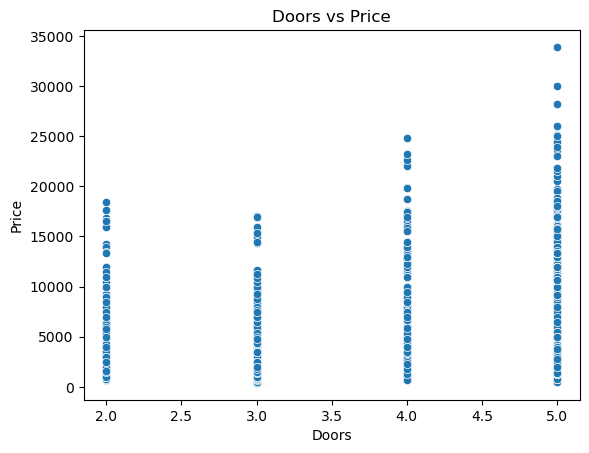

In [46]:
eda_column(car_df, "Doors")

<span style="color: #1e90ff;">13. Doors 컬럼 분석결과</span>    
Doors는 총 3,662개의 값이 있으며 평균은 약 4.32개, 중앙값은 5개다. 최소 2개에서 최대 5개까지 분포하며, 하위 25%는 3개 이하, 상위 25%는 5개 이상으로 나타난다.

- 2 / 3 / 4 / 5 도어 분포

- 3-door vs 5-door 가격 차이

- 결측이 특정 body type에 몰려 있는지


===== Seats =====


count    3594.000000
mean        4.898442
std         0.575483
min         2.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         7.000000
Name: Seats, dtype: float64

np.int64(6)

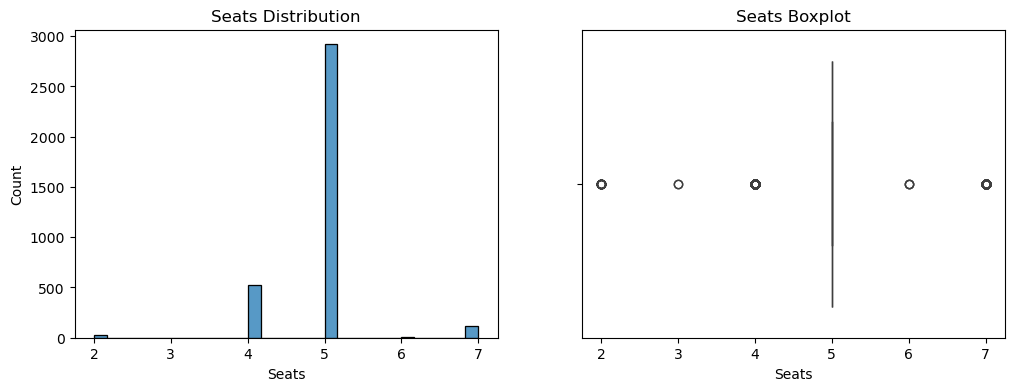

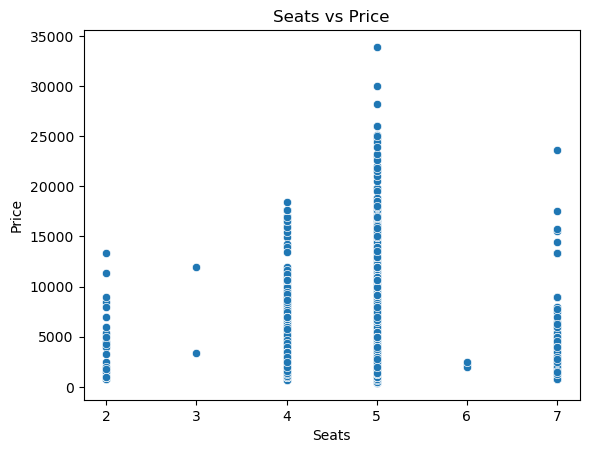

In [47]:
eda_column(car_df, "Seats")

<span style="color: #1e90ff;">14. Seats 컬럼 분석결과</span>    
Seats는 총 3,652개의 값이 있으며 평균은 약 4.90개, 중앙값은 5개다. 최소 2개에서 최대 7개까지 분포하고, 하위 25%는 5개 이하, 상위 25%도 5개 이상으로 나타난다.

- 2 / 4 / 5 / 7 좌석 가격 차이

- SUV / MPV와 강한 연관

- 7-seater가 가격 상단에 몰리는지

In [48]:
eda_column(car_df, "Emission Class")


===== Emission Class =====


count       3600
unique         6
top       Euro 5
freq        1257
Name: Emission Class, dtype: object

np.int64(0)

Emission Class
Euro 5    1257
Euro 6    1109
Euro 4    1068
Euro 3     137
Euro 2      25
Euro 1       4
Name: count, dtype: int64

<span style="color: #1e90ff;">15. Emission Class 컬럼 분석결과</span>   
차량의 배출가스 기준(환경 규제 등급)   
Emission Class는 총 3,600개의 값이 있으며 서로 다른 등급은 6개다. 가장 많이 등장한 등급은 Euro 5이고 1,257회 나타났다.